## Gaussian Process Regression: Basic Introductry Example
GPR Practice v1.00

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'True generative process')

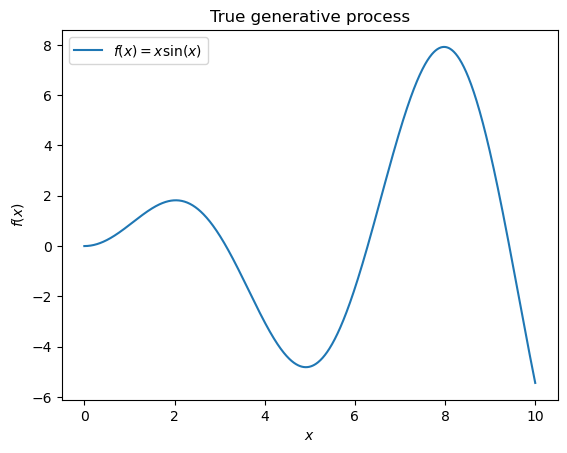

In [4]:
x = np.linspace(0,10,1000).reshape(-1,1)
y = np.squeeze(x * np.sin(x))
plt.plot(x,y,label=r"$f(x) = x \sin(x)$")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("True generative process")

Generating Training dataset

Text(0.5, 1.0, 'Training Samples')

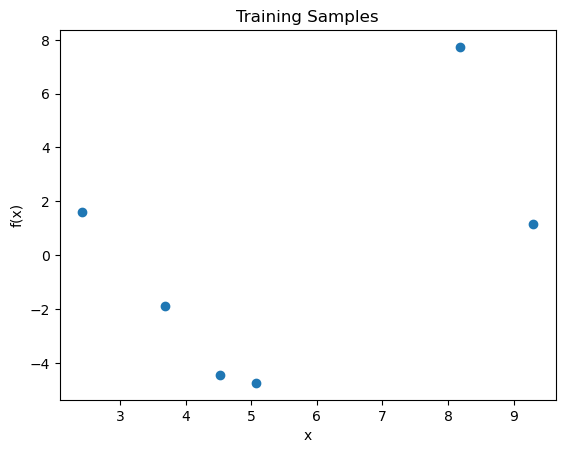

In [5]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
x_train, y_train = x[training_indices], y[training_indices]

plt.scatter(x_train, y_train)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Training Samples")

GPR Fitting

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

kernel = 1 * RBF(length_scale=1.0)
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=99)
gaussian_process.fit(x_train, y_train)
gaussian_process.kernel_

5.02**2 * RBF(length_scale=1.43)

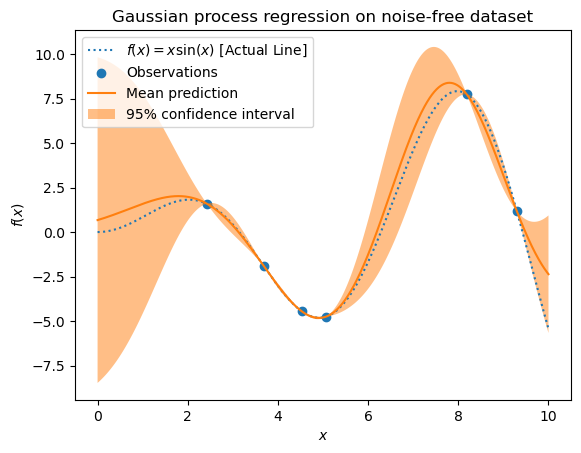

In [7]:
mean_prediction, std_prediction = gaussian_process.predict(x, return_std=True)

plt.plot(x, y, label=r"$f(x) = x \sin(x)$ [Actual Line]", linestyle="dotted")
plt.scatter(x_train, y_train, label="Observations")
plt.plot(x, mean_prediction, label="Mean prediction")
plt.fill_between(
    x.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")